# Univariate Analysis : 
- when you Analyse each column independently
- you can also call that column a variable, so that is how it is called **Univariate Analysis**

# Bi-Variate Analysis:
- when you analyse two columns at a time that is called **Bi-Variate Analysis**

# Multi-Variate Analysis:
- when you analyse more than two columns at a time that is called **Multi-Variate Analysis**

In [5]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

## Steps :
- 1. Analyse the type of data **Numerical or Catgorical**
- 2. Then we plot it or use the tools
  3. in univariate analysis our most of the focus is ploting and understanding data
  4. So, after we import data we analyse the data usuing those 7 questions
  5. After that we will perform EDA, from left to right (genreally), but for this example we are doing for categorical first then numerical columns
  6. First you have knowledge about your data, that which thing represents what.
  7. Identify useful columns

In [6]:
df = pd.read_csv('tested.csv')

In [7]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,0,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,1,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,0,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,0,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,1,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


# Categorical
- Pclass and Survived EDA

### 1. Countplot 
- so to check how much passengers have survived we use this (wo visualize categories)

<Axes: xlabel='Survived', ylabel='count'>

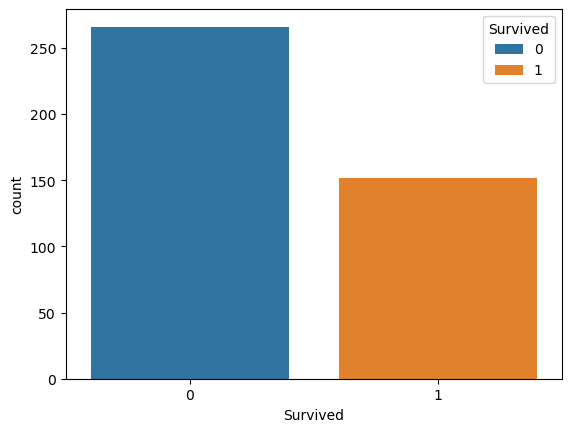

In [30]:
sns.countplot(x = 'Survived', data = df, hue = 'Survived')

### PieChart
- same info but in percentages form

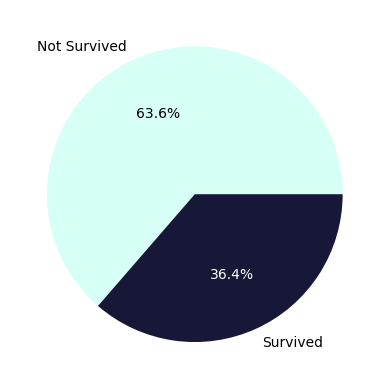

In [85]:
wedges,autotext,texts = plt.pie(df['Survived'].value_counts(), labels = ['Not Survived', 'Survived'], autopct='%1.1f%%', colors = ['#d6fff6','#171738'])
texts[1].set_color('White')

## Experiments

C:\Users\DELL\AppData\Local\Temp\ipykernel_7172\3054727747.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x = 'Survived', data = df, palette = 'dark')


<Axes: xlabel='Survived', ylabel='count'>

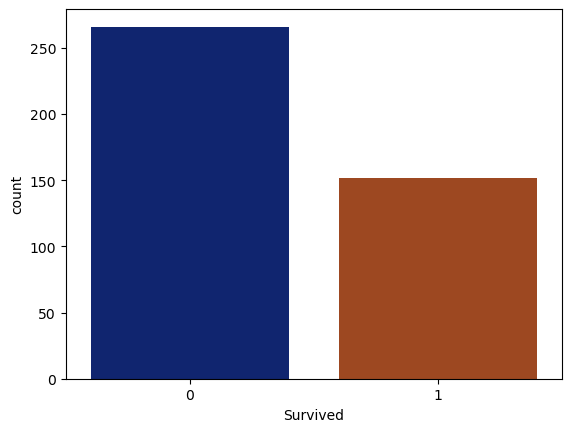

In [31]:
sns.countplot(x = 'Survived', data = df, palette = 'dark')

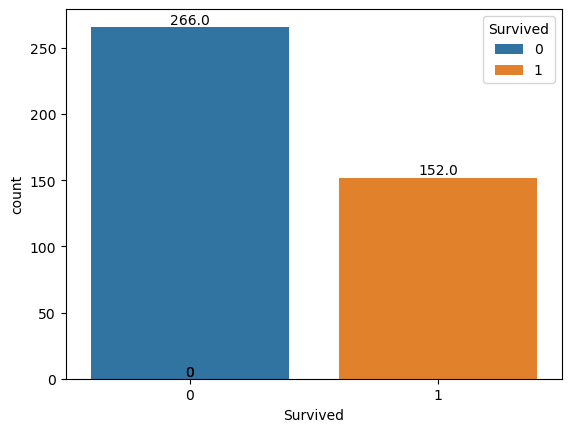

In [33]:
ax = sns.countplot(x='Survived', hue='Survived', data=df)

# Add counts on top of bars
for p in ax.patches:
    height = p.get_height()
    ax.annotate(f'{height}', 
                (p.get_x() + p.get_width() / 2., height), 
                ha='center', va='bottom')

plt.show()


In [49]:
df.groupby('Pclass')[['Survived']].mean()

,Survived
Pclass,
1,0.467290
2,0.322581
3,0.330275


<Axes: xlabel='Survived'>

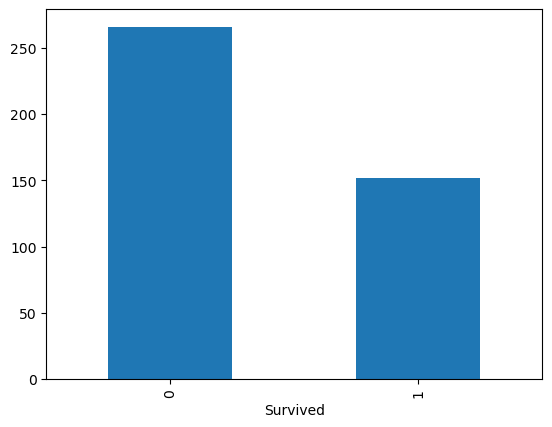

In [34]:
df['Survived'].value_counts().plot(kind = 'bar')

C:\Users\DELL\AppData\Local\Temp\ipykernel_7172\2183438920.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x = 'Pclass', data = df, palette = 'dark')


<Axes: xlabel='Pclass', ylabel='count'>

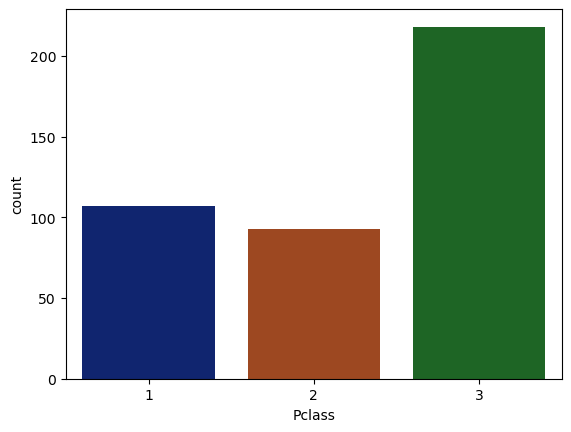

In [35]:
sns.countplot(x = 'Pclass', data = df, palette = 'dark')

In [51]:
df.groupby(by='Pclass').mean(numeric_only=True)


,PassengerId,Survived,Age,SibSp,Parch,Fare
Pclass,,,,,,
1,1098.224299,0.467290,40.918367,0.476636,0.383178,94.280297
2,1117.935484,0.322581,28.777500,0.376344,0.344086,22.202104
3,1094.178899,0.330275,24.027945,0.463303,0.417431,12.459678


In [59]:
class_counts = df['Pclass'].value_counts()

# Map those counts back into a new column
df['ClassCount'] = df['Pclass'].map(class_counts)

df.head()


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,ClassCount
0,892,0,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q,218
1,893,1,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S,218
2,894,0,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q,93
3,895,0,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S,218
4,896,1,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S,218


In [60]:
 df['Pclass'].value_counts()

Pclass
3    218
1    107
2     93
Name: count, dtype: int64

# Numerical Data

## a. Histogram
- it is used to make numerical data behave like categorical data
- You can create ranges/ bins in the data
- So, it plots a range of data
    - For example : if you have data of people age, rangine from 0 - 80, it can create 8 bins (Each of 10 yrs gap) such as 0-10,11-20... and plot the count of it
- This is used show a range or distribution of data
- arg bin (change it to change the number of bins)
- output is a plot and two array, 1st array tells the height of the bars and 2nd one tells the bin edges i.e the range of a bin

(array([15., 10., 36., 81., 64., 37., 28., 30., 15., 11.,  4.,  1.]),
 array([ 0.17      ,  6.48916667, 12.80833333, 19.1275    , 25.44666667,
        31.76583333, 38.085     , 44.40416667, 50.72333333, 57.0425    ,
        63.36166667, 69.68083333, 76.        ]),
 <BarContainer object of 12 artists>)

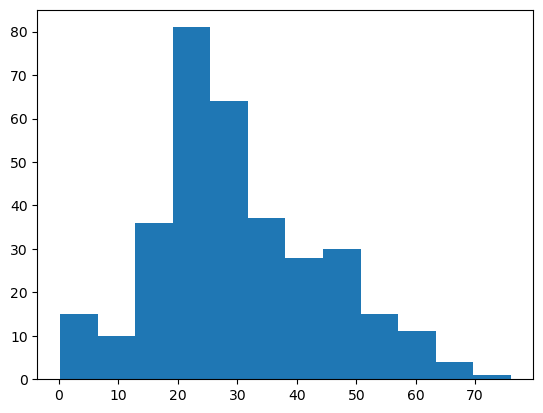

In [94]:
plt.hist(df['Age'], bins= 12) 


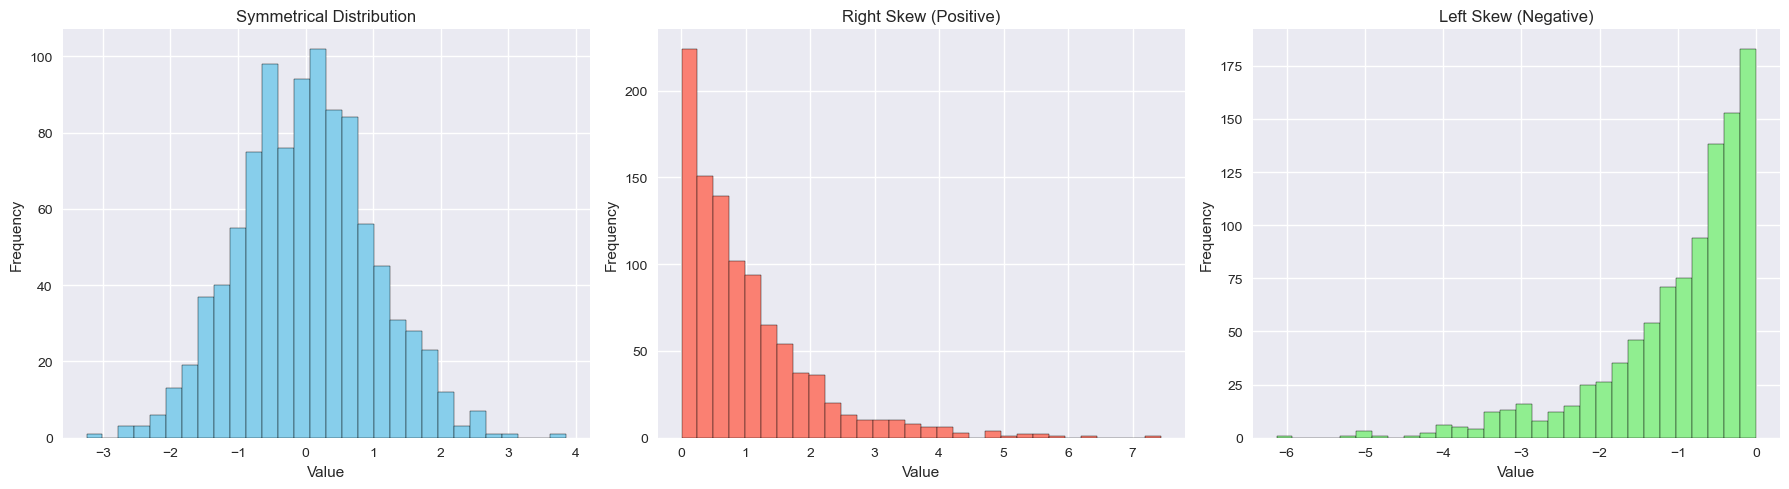

In [96]:
import matplotlib.pyplot as plt
import numpy as np

# Set seed for reproducibility
np.random.seed(42)

# Generate datasets
symmetrical_data = np.random.normal(loc=0, scale=1, size=1000)   # Normal distribution
right_skewed_data = np.random.exponential(scale=1, size=1000)    # Positive skew
left_skewed_data = -np.random.exponential(scale=1, size=1000)    # Negative skew

# Create subplots
plt.style.use('seaborn-v0_8')
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Symmetrical histogram
axes[0].hist(symmetrical_data, bins=30, color='skyblue', edgecolor='black')
axes[0].set_title('Symmetrical Distribution')
axes[0].set_xlabel('Value')
axes[0].set_ylabel('Frequency')

# Right skewed histogram
axes[1].hist(right_skewed_data, bins=30, color='salmon', edgecolor='black')
axes[1].set_title('Right Skew (Positive)')
axes[1].set_xlabel('Value')
axes[1].set_ylabel('Frequency')

# Left skewed histogram
axes[2].hist(left_skewed_data, bins=30, color='lightgreen', edgecolor='black')
axes[2].set_title('Left Skew (Negative)')
axes[2].set_xlabel('Value')
axes[2].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

## b. Distplot
- That is same as histogram but there is one difference
- it shows the curve which is called KDE
### KDE :
    - It is Kernel Density Estimation, it pass through touching the histogram
    - it shows the distribution of data, we call it **PDF** : Probability Density Function (As it shows probability)
    - on Y-axis there is Probability of one on the X-axis
    - It also tells the skewness of data
    for Example : If you pick one random passenger, the probability of him having age 40 will be almost less than 2 (0.02 *100)

### Seaborn: distplot vs displot

#### distplot (Deprecated)
- **Type:** Axes-level function (works on a single plot).
- **Status:** Removed in Seaborn v0.11.
- **Purpose:** Plots a histogram and optionally overlays a KDE (kernel density estimate).
- **Limitations:** Overloaded, less flexible, no support for faceting.
- **Example:**
  ```python
  import seaborn as sns
  import numpy as np

  data = np.random.randn(1000)
  sns.distplot(data, kde=True, bins=30)

#### Seaborn: displot

#### Overview
- **Type:** Figure-level function (creates full figures, supports multiple subplots/facets).
- **Introduced:** Seaborn v0.11 (modern replacement for `distplot`).
- **Purpose:** Flexible visualization — can plot histograms (`kind="hist"`) or KDEs (`kind="kde"`).
- **Advantages:** 
  - More powerful than `distplot`
  - Supports faceting (multiple plots in one figure)
  - Actively supported and recommended

---

#### Usage Examples

#### Histogram + KDE
```python
import seaborn as sns
import numpy as np

data = np.random.randn(1000)
sns.displot(data, kde=True, bins=30)

In [118]:
df['Age'].skew() # if 0 perfectly skewed
# if +ve, +ve skew
# if -ve, -ve skew

np.float64(0.4573612871503845)

C:\Users\DELL\AppData\Local\Temp\ipykernel_7172\3255828239.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['Age'])


<Axes: xlabel='Age', ylabel='Density'>

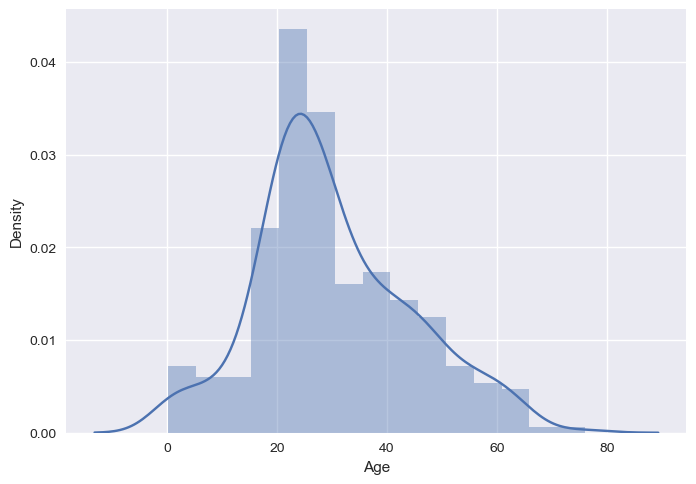

In [98]:
sns.distplot(df['Age'])

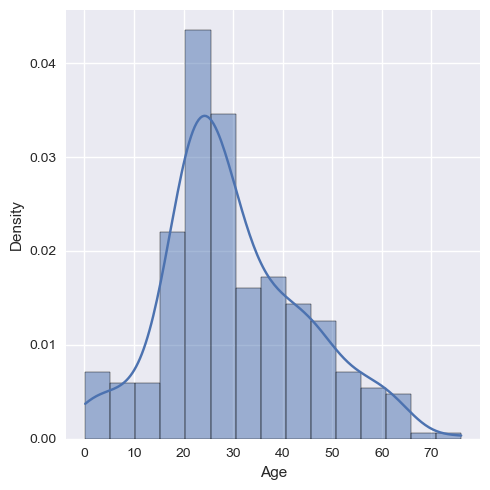

In [111]:
sns.displot(df['Age'], kde= True, stat="density")

## c. Boxplot
- It gives 5-Number summary
- Check notes for more info.

<Axes: xlabel='Age'>

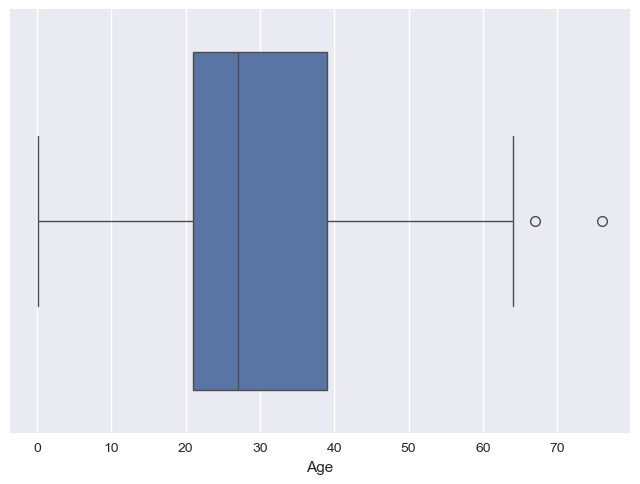

In [113]:
sns.boxplot(x =df['Age'])

In [115]:
df['Age'].min()

0.17

In [116]:
df['Age'].max()

76.0

In [117]:
df['Age'].mean()

np.float64(30.272590361445783)

In [120]:
df['Age'].std()

14.18120923562442

<Axes: xlabel='Fare'>

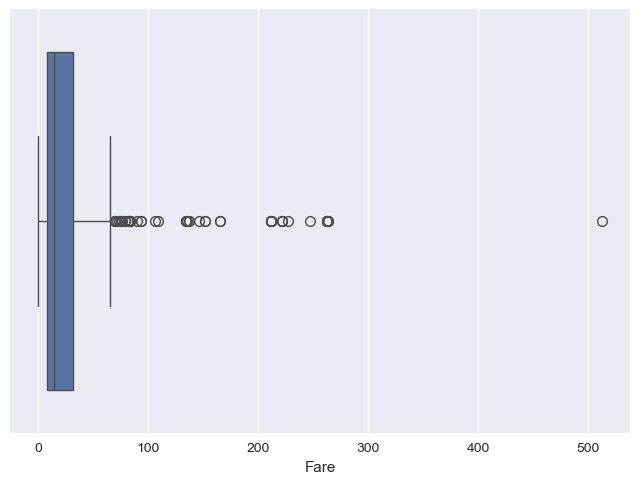

In [114]:
sns.boxplot(x =df['Fare'])

- There are plots other than these but are not generally used 